In [315]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from models.pendulum.model import CD_Detector
import torch

import glob
from sklearn.metrics import precision_recall_curve, auc, f1_score
from algs.cd_poly import CDPolynomial

In [2]:
ckpt = glob.glob('lightning_logs/version_13/checkpoints/*.ckpt')[0]
model = CD_Detector.load_from_checkpoint(ckpt).to('cpu')

In [316]:
n_eps = 1000

def process_data(file: str):
    npz = np.load(file)
    trip = npz["trip"]
    r = npz["rew"]
    param = npz["param"]

    cols = [f"s{i}" for i in range(4)] + [f"a{i}" for i in range(1)] + [f"ns{i}" for i in range(4)]
    df = pd.DataFrame(
        data=trip,
        columns=cols
    )
    df['step'] = np.array([[i for i in range(100)] for j in range(n_eps)]).flatten()
    df['t'] = df['step'] / 100
    df['ep'] = np.array([[i] * 100 for i in range(n_eps)]).flatten()
    df['r'] = r
    df['damp'] = np.concatenate([np.full((100,), param[i]) for i in range(n_eps)])

    df["cum_r"] = df.groupby('ep')['r'].cumsum()

    fail = df.groupby('ep')['r'].min() == 0.0
    df['fail'] = fail[df['ep']].values
    print(len(df[~df['fail']]) / len(df))
    return df

def get_tsa(df):
    return df[['t', 's0', 's1', 's2', 's3', 'a0']].to_numpy()

In [317]:
df_tr = process_data('train2.npz')
df_te = process_data('test.npz')

0.559
0.523


In [318]:
p = CDPolynomial(get_tsa(df_tr[~df_tr['fail']]), degree=5, verbose=True, basis='cheb', eps=0)
df_tr['cd'] = np.log(p(get_tsa(df_tr)))
df_te['cd'] = np.log(p(get_tsa(df_te)))

df_tr_succ = df_tr[~df_tr['fail']]
df_tr_fail = df_tr[df_tr['fail']]
df_te_succ = df_te[~df_te['fail']]
df_te_fail = df_te[df_te['fail']]
#df_tr_succ['cd'] = np.log(model(torch.from_numpy(df_tr_succ.iloc[:,:9].to_numpy()).float()).numpy())
#df_tr_fail['cd'] = np.log(model(torch.from_numpy(df_tr_fail.iloc[:,:9].to_numpy()).float()).numpy())

Data monomials shape: torch.Size([55900, 462])
Moment matrix cond num: 4.042468e+15
Empirical mean of CD poly: 469.6519775390625


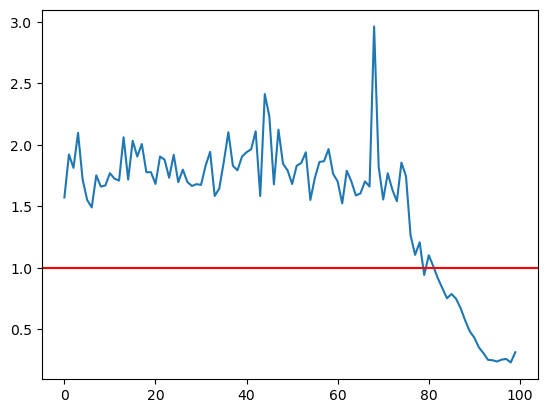

In [319]:
plt.plot(df_te_succ.groupby('step')['cd'].max() / df_te_fail.groupby('step')['cd'].min())
plt.axhline(1., color='red')

<Axes: xlabel='step'>

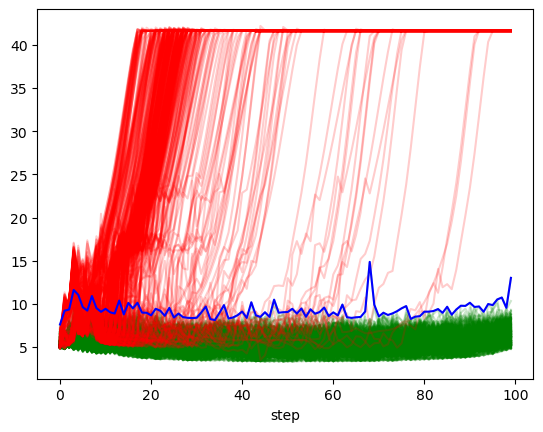

In [321]:
for i in df_te[~df_te['fail']]['ep'].unique():
    plt.plot(range(100), df_te[~df_te['fail']][df_te[~df_te['fail']]['ep'] == i]['cd'], color='green', alpha=0.2)

for i in df_te[df_te['fail']]['ep'].unique():
    plt.plot(range(100), df_te[df_te['fail']][df_te[df_te['fail']]['ep'] == i]['cd'], color='red', alpha=0.2)

df_te[~df_te['fail']].groupby('step')['cd'].quantile(1.).plot(color='blue')
#plt.gca().axhline(best_thresh)

#plt.xlim(0, 20)

In [295]:
y_true = df_te.groupby('ep')['fail'].min()
y_pred = df_te.groupby('ep')['cd'].max()

precision, recall, thresh = precision_recall_curve(y_true, y_pred)
auc(recall, precision)

1.0

In [297]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresh[best_idx]
best_thresh = df_tr_succ['cd'].max()
best_thresh

10.91764

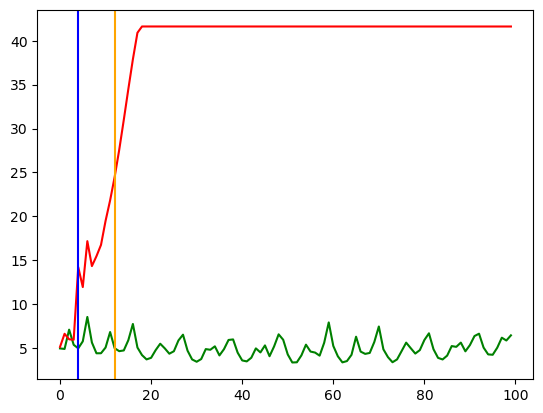

In [307]:
df = df_te_fail.pivot(index='ep', columns='step', values=['cd', 'r']).sample(1)
plt.plot(df_te_succ.pivot(index='ep', columns='step', values='cd').sample(1).values.T, color='green')
plt.plot(df['cd'].values.T, color='red')

plt.axvline((df['cd'].values >= best_thresh).argmax(), color='blue')
plt.axvline(df['r'].values.argmin(), color='orange')

Text(0, 0.5, 'precision')

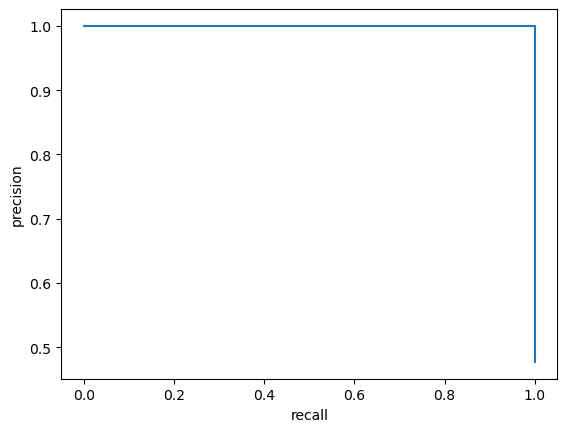

In [308]:
plt.plot(recall, precision)
plt.xlabel('recall')
plt.ylabel('precision')

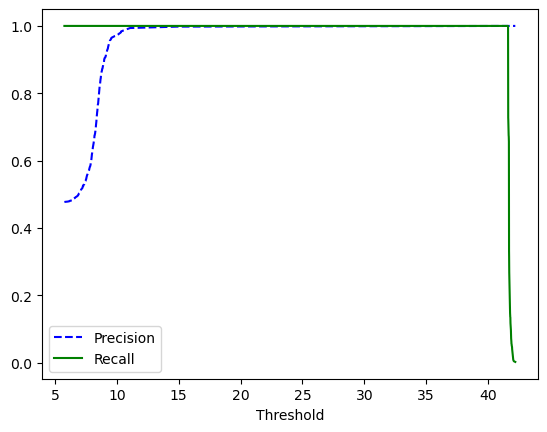

In [309]:
plt.plot(thresh, precision[:-1], "b--", label="Precision")
plt.plot(thresh, recall[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()
#plt.xlim(48, 52)

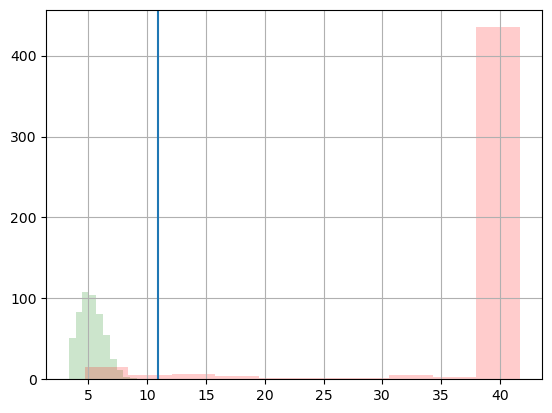

In [310]:
step = 40
df_te_succ[df_te_succ['step'] == step]['cd'].hist(alpha=0.2, color='green')
df_te_fail[df_te_fail['step'] == step]['cd'].hist(alpha=0.2, color='red')
plt.gca().axvline(best_thresh)

In [311]:
df_te_fail_step = df_te_fail.loc[df_te_fail.groupby('ep')['r'].idxmin()]['step'].to_numpy()
df_te_fail_pred = df_te_fail[df_te_fail['cd'] >= best_thresh].groupby('ep', as_index=False).first()['step'].to_numpy()

In [312]:
np.mean(df_te_fail_pred < df_te_fail_step)

1.0

In [314]:
ttd = (df_te_fail_step - df_te_fail_pred).mean()
ttd

14.920335429769391